EDA

In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import pandas as pd



In [5]:
corpus = pd.read_json("../data/raw/scifact/corpus.jsonl", lines=True)
queries = pd.read_json("../data/raw/scifact/queries.jsonl", lines=True)
qrels = pd.read_csv("../data/raw/scifact/qrels/test.tsv", sep="\t")

In [4]:
print(f"Dokument: {len(corpus)}")
print(f"Queries: {len(queries)}")
print(f"Qrels: {len(qrels)}")

Dokument: 5183
Queries: 1109
Qrels: 339


In [5]:
corpus.head()

,_id,title,text,metadata
0,4983,Microstructural development of human newborn c...,Alterations of the architecture of cerebral wh...,{}
1,5836,Induction of myelodysplasia by myeloid-derived...,Myelodysplastic syndromes (MDS) are age-depend...,{}
2,7912,"BC1 RNA, the transcript from a master gene for...",ID elements are short interspersed elements (S...,{}
3,18670,The DNA Methylome of Human Peripheral Blood Mo...,DNA methylation plays an important role in bio...,{}
4,19238,The human myelin basic protein gene is include...,Two human Golli (for gene expressed in the oli...,{}


In [6]:
queries.head()

,_id,text,metadata
0,0,0-dimensional biomaterials lack inductive prop...,{}
1,2,1 in 5 million in UK have abnormal PrP positiv...,"{'13734012': [{'sentences': [4], 'label': 'CON..."
2,4,1-1% of colorectal cancer patients are diagnos...,{}
3,6,10% of sudden infant death syndrome (SIDS) dea...,{}
4,9,32% of liver transplantation programs required...,"{'44265107': [{'sentences': [15], 'label': 'SU..."


In [7]:
qrels.head()

,query-id,corpus-id,score
0,1,31715818,1
1,3,14717500,1
2,5,13734012,1
3,13,1606628,1
4,36,5152028,1


In [8]:
corpus["word_count"] = corpus["text"].str.split().str.len()
corpus["word_count"].describe()

count    5183.000000
mean      201.810920
std        86.007594
min        26.000000
25%       147.000000
50%       192.000000
75%       247.000000
max      1524.000000
Name: word_count, dtype: float64

<Axes: >

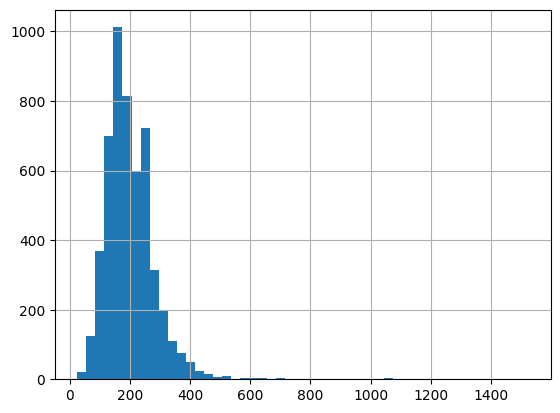

In [9]:
corpus["word_count"].hist(bins=50)

In [10]:
queries["word_count"] = queries["text"].str.split().str.len()
queries["word_count"].describe()

count    1109.000000
mean       12.379621
std         4.795566
min         3.000000
25%         9.000000
50%        12.000000
75%        15.000000
max        39.000000
Name: word_count, dtype: float64

In [11]:
qrels.groupby("query-id")["corpus-id"].count().describe()

count    300.000000
mean       1.130000
std        0.529813
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        5.000000
Name: corpus-id, dtype: float64

In [12]:
import sys

sys.path.append("../src")

from exjobb_rag.data_loader import create_corpus_table

table = create_corpus_table()
table.head()


pyarrow.Table
_id: int64
title: large_string
text: large_string
metadata: struct<>
----
_id: [[4983,5836,7912,18670,19238]]
title: [["Microstructural development of human newborn cerebral white matter assessed in vivo by diffusion t (... 33 chars omitted)","Induction of myelodysplasia by myeloid-derived suppressor cells.","BC1 RNA, the transcript from a master gene for ID element amplification, is able to prime its own  (... 22 chars omitted)","The DNA Methylome of Human Peripheral Blood Mononuclear Cells","The human myelin basic protein gene is included within a 179-kilobase transcription unit: expressi (... 45 chars omitted)"]]
text: [["Alterations of the architecture of cerebral white matter in the developing human brain can affect  (... 1711 chars omitted)","Myelodysplastic syndromes (MDS) are age-dependent stem cell malignancies that share biological fea (... 1496 chars omitted)","ID elements are short interspersed elements (SINEs) found in high copy number in many rodent genom (.

In [13]:
print(f"Antal rader: {table.count_rows()}")

Antal rader: 5183


In [16]:
from exjobb_rag.embeddings import embed_texts
from exjobb_rag.embeddings import embed_corpus
vecs = embed_texts(["hello world", "this is a test"])
print(f"Antal vektorer: {len(vecs)}")
print(f"Dimensioner per vektor: {len(vecs[0])}")



Batches: 100%|██████████| 1/1 [00:00<00:00,  5.69it/s]

Antal vektorer: 2
Dimensioner per vektor: 1024


In [18]:
import lancedb
db = lancedb.connect("../data/lancedb")
table = db.open_table("corpus_embeddings")
print(f"Antal rader: {table.count_rows()}")
print(table.schema)

Antal rader: 5183
_id: int64
title: large_string
text: large_string
metadata: struct<>
vector: fixed_size_list<item: float>[1024]
  child 0, item: float


In [9]:
from exjobb_rag.search import semantic_search                                                                                                     

results = semantic_search("Adult tissue-resident macrophages are seeded before birth.", k=5)
print(results[["_id", "title", "_distance"]])

        _id                                              title  _distance
0  12827098  Tissue-resident macrophages self-maintain loca...   0.192303
1  22406695        Origin and functions of tissue macrophages.   0.212737
2   7521113  Fate mapping reveals origins and dynamics of m...   0.231573
3  25068298  Electron microscopic studies of macrophages in...   0.237468
4  22973574  A lineage of myeloid cells independent of Myb ...   0.238367


In [6]:
queries["text"].head(5)

0    0-dimensional biomaterials lack inductive prop...
1    1 in 5 million in UK have abnormal PrP positiv...
2    1-1% of colorectal cancer patients are diagnos...
3    10% of sudden infant death syndrome (SIDS) dea...
4    32% of liver transplantation programs required...
Name: text, dtype: str